ESERCIZIO

Urilizza l'Autoencoder della lezione, seleziona due immagini del test set (es. 4 e 8)
Estrai i loro vettori latenti tramite l'encoder
Genera 10 vettori intermedi usanto l'interpolazione lineare e usa il decode per visualizzare la trasformazione
Cosa noti nel punto centrale (t=0.52)?

Inizio addestramento: il modello sta imparando le caratteristiche visive delle cifre...
Ricerca delle cifre 4 e 8 nel dataset di test...
Generazione trasformazione tra la cifra 4 (indice 4) e la cifra 8 (indice 61)...


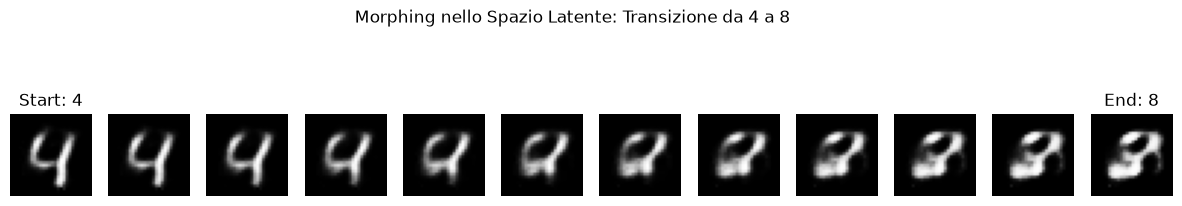

In [1]:
import os

# Configurazione del backend di Keras.
# Impostiamo PyTorch come motore di calcolo prima dell'importazione di Keras.
# Questo definisce chi eseguirà effettivamente le operazioni matematiche (calcoli tensoriali).
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARAZIONE DEI DATI ---
# Carichiamo il dataset MNIST.
# Importante: manteniamo y_test perché ci serve per trovare specificamente i numeri 4 e 8 per l'esercizio.
# x_train/x_test contengono le immagini (dati pixel).
# y_test contiene le etichette (che numero è l'immagine?), utile per la selezione mirata.
(x_train, _), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizzazione: scaliamo i valori dei pixel da [0, 255] a [0, 1].
# Questo aiuta l'algoritmo di ottimizzazione (Adam) a convergere più velocemente e stabilmente.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape: trasformiamo le immagini da matrici 28x28 a vettori piatti di 784 elementi.
# I layer 'Dense' (completamente connessi) richiedono vettori unidimensionali come input, non griglie.
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# --- 2. ARCHITETTURA DEL MODELLO (Autoencoder) ---
# L'autoencoder si basa su due componenti principali: 
# 1. Encoder: comprime l'input in uno spazio latente (codice rappresentativo compatto).
# 2. Decoder: ricostruisce l'input originale partendo dallo spazio latente.

# Dimensione latente: il numero di neuroni nel "collo di bottiglia". 
# Costringe la rete a imparare una rappresentazione sintetica (32 numeri per descrivere un'intera cifra).
latent_dim = 32 

# --- Costruzione dell'Encoder ---
# Definiamo l'ingresso: ci aspettiamo un vettore di 784 pixel.
inputs = keras.Input(shape=(784,))

# Primo strato di compressione: riduciamo da 784 a 128 neuroni.
# Estrae caratteristiche di alto livello dall'immagine grezza.
x = layers.Dense(128, activation="relu")(inputs)

# Strato latente: il punto di massima compressione (32 neuroni).
latent_repr = layers.Dense(latent_dim, activation="relu", name="Latent_Space")(x)

# Istanziamo il modello Encoder: Immagine (784) -> Codice Latente (32)
encoder = keras.Model(inputs, latent_repr, name="Encoder")

# --- Costruzione del Decoder ---
# Definiamo l'ingresso: il codice compresso generato dall'encoder.
latent_inputs = keras.Input(shape=(latent_dim,))

# Primo strato di ricostruzione: espandiamo da 32 a 128 neuroni.
x = layers.Dense(128, activation="relu")(latent_inputs)

# Strato di uscita: riportiamo alla dimensione originale (784).
# Usiamo 'sigmoid' per forzare i valori tra 0 e 1, corrispondenti ai nostri dati normalizzati in input.
outputs = layers.Dense(784, activation="sigmoid")(x)

# Istanziamo il modello Decoder: Codice Latente (32) -> Immagine Ricostruita (784)
decoder = keras.Model(latent_inputs, outputs, name="Decoder")

# --- Autoencoder Completo ---
# Colleghiamo Encoder e Decoder: Input -> Encoder -> Decoder -> Output
# La rete viene addestrata "end-to-end": l'errore fluisce dall'output indietro fino all'input.
autoencoder = keras.Model(inputs, decoder(encoder(inputs)))

# Compilazione: definisce come la rete impara.
# Loss 'mse' (Mean Squared Error): calcola la differenza media al quadrato tra pixel originali e pixel ricostruiti.
# Optimizer 'adam': aggiorna i pesi della rete passo dopo passo per minimizzare la loss.
autoencoder.compile(optimizer="adam", loss="mse")

# Addestramento
# x_train è sia input (x) che target (y).
# Il modello cerca di imparare la funzione identità f(x) = x, passando però per una compressione forzata.
print("Inizio addestramento: il modello sta imparando le caratteristiche visive delle cifre...")
autoencoder.fit(x_train, x_train, epochs=5, batch_size=256, verbose=0)

# --- 3. INTERPOLAZIONE E MORPHING (Da 4 a 8) ---
print("Ricerca delle cifre 4 e 8 nel dataset di test...")

# Utilizziamo numpy per trovare gli indici della prima occorrenza di un '4' e di un '8'.
# y_test == 4 restituisce un array booleano; np.where restituisce gli indici dove è True.
idx_4 = np.where(y_test == 4)[0][0]
idx_8 = np.where(y_test == 8)[0][0]

def interpolate_digits(digit_a_idx, digit_b_idx, steps=10):
    """
    Genera una sequenza di immagini che trasformano gradualmente la cifra A nella cifra B.
    Sfrutta lo spazio latente per creare transizioni basate sulle caratteristiche interne
    apprese dalla rete, invece di una semplice dissolvenza pixel-per-pixel.
    """
    # 1. Selezioniamo le immagini singole dal test set
    img_a = x_test[digit_a_idx : digit_a_idx + 1]
    img_b = x_test[digit_b_idx : digit_b_idx + 1]
    
    # 2. Encoder: Immagine -> Spazio Latente
    # Otteniamo le coordinate nello spazio a 32 dimensioni (z) per le due cifre.
    z_a = encoder.predict(img_a, verbose=0)
    z_b = encoder.predict(img_b, verbose=0)
    
    # 3. Interpolazione Lineare (lerp) nello spazio latente
    # Calcoliamo punti intermedi sulla retta che collega z_a a z_b.
    # Formula: z_t = (1-t)*z_a + t*z_b
    t_values = np.linspace(0, 1, steps)
    interpolated_latents = [(1 - t) * z_a + t * z_b for t in t_values]
    
    # vstack impila i vettori latenti in un unico batch da processare insieme
    interpolated_latents = np.vstack(interpolated_latents).astype("float32")
    
    # 4. Decoder: Spazio Latente -> Immagine Ricostruita
    # Il decoder interpreta questi "punti misti" come nuove immagini ibride.
    reconstructions = decoder.predict(interpolated_latents, verbose=0)
    
    return ops.convert_to_numpy(reconstructions)

# Eseguiamo il morphing tra il 4 (trovato a idx_4) e l'8 (trovato a idx_8)
print(f"Generazione trasformazione tra la cifra 4 (indice {idx_4}) e la cifra 8 (indice {idx_8})...")
morph_sequence = interpolate_digits(idx_4, idx_8, steps=12)

# --- 4. VISUALIZZAZIONE DEI RISULTATI ---
plt.figure(figsize=(15, 3))
for i, img in enumerate(morph_sequence):
    ax = plt.subplot(1, 12, i + 1)
    
    # Reshape per visualizzare il vettore piatto (784,) come immagine quadrata (28x28)
    plt.imshow(img.reshape(28, 28), cmap="gray")
    plt.axis("off")
    
    # Aggiungiamo etichette chiare per inizio e fine
    if i == 0: 
        plt.title("Start: 4")
    elif i == 11: 
        plt.title("End: 8")

plt.suptitle("Morphing nello Spazio Latente: Transizione da 4 a 8")
plt.show()